<a href="https://colab.research.google.com/github/thakurdeepali/LP2/blob/main/brain_tumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow opencv-python matplotlib seaborn scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

In [3]:
from google.colab import files
uploaded = files.upload()

Saving kaggle (1).json to kaggle (1).json


In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [5]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:01<00:00, 145MB/s]



In [6]:
!unzip brain-tumor-mri-dataset.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/Training/glioma/Tr-gl_279.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_28.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_280.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_281.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_282.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_283.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_284.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_285.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_286.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_287.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_288.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_289.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_29.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_290.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_291.jpg  
  inflating: /content

In [7]:
import os
print(os.listdir('/content/dataset'))

['Testing', 'Training']


In [8]:
print(os.listdir('/content/dataset/Training'))

['glioma', 'pituitary', 'meningioma', 'notumor']


In [9]:
import os

total_images = 0
dataset_path = '/content/dataset/Training'

for root, dirs, files in os.walk(dataset_path):
    total_images += len(files)

print("Total Images:", total_images)

Total Images: 5600


In [10]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS_CNN = 20
EPOCHS_RESNET = 30

# IMPORTANT: set correct path after loading dataset
DATASET_PATH = "/content/dataset/Training"

In [11]:
# Check dataset structure
print("Dataset folders:", os.listdir(DATASET_PATH))

# Count images per class
for category in os.listdir(DATASET_PATH):
    path = os.path.join(DATASET_PATH, category)
    print(category, ":", len(os.listdir(path)), "images")

Dataset folders: ['glioma', 'pituitary', 'meningioma', 'notumor']
glioma : 1400 images
pituitary : 1400 images
meningioma : 1400 images
notumor : 1400 images


In [12]:
# ImageDataGenerator is used for:
# 1. Normalization (scaling pixel values)
# 2. Data augmentation (rotate, flip, zoom)
# 3. Splitting data into training & validation

train_datagen = ImageDataGenerator(
    rescale=1./255,            # Normalize pixel values (0–1)
    rotation_range=15,         # Rotate images
    zoom_range=0.1,            # Zoom images
    horizontal_flip=True,      # Flip images horizontally
    validation_split=0.2       # 80% training, 20% validation
)

# Load training data
train_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),   # Resize images
    batch_size=BATCH_SIZE,
    class_mode='categorical',           # Multi-class classification
    subset='training'
)

# Load validation data
val_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.


In [13]:
# Build a simple CNN model (Baseline model)

cnn_model = Sequential()

# First convolution layer (extract basic features)
cnn_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
cnn_model.add(MaxPooling2D(2,2))   # Reduce dimensions

# Second convolution layer
cnn_model.add(Conv2D(64, (3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))

# Third convolution layer
cnn_model.add(Conv2D(128, (3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))

# Flatten feature maps into 1D vector
cnn_model.add(Flatten())

# Fully connected layer
cnn_model.add(Dense(128, activation='relu'))

# Dropout layer to prevent overfitting
cnn_model.add(Dropout(0.5))

# Output layer (4 classes)
cnn_model.add(Dense(4, activation='softmax'))

# Compile model
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train CNN model

history_cnn = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_CNN
)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 373s 3s/step - accuracy: 0.6125 - loss: 0.9057 - val_accuracy: 0.7437 - val_loss: 0.6231
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 379s 3s/step - accuracy: 0.7556 - loss: 0.6158 - val_accuracy: 0.7830 - val_loss: 0.5289
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 368s 3s/step - accuracy: 0.7873 - loss: 0.5429 - val_accuracy: 0.7991 - val_loss: 0.4716
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 372s 3s/step - accuracy: 0.8141 - loss: 0.4897 - val_accuracy: 0.8250 - val_loss: 0.4528
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 362s 3s/step - accuracy: 0.8268 - loss: 0.4488 - val_accuracy: 0.8339 - val_loss: 0.4136
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 368s 3s/step - accuracy: 0.8438 - loss: 0.4030 - val_accuracy: 0.8509 - val_loss: 0.3762
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 384s 3s/step - accuracy: 0.8540 - loss: 0.3766 - val_accuracy: 0.8366 - val_loss: 0.3947
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 364s 3s/step - accuracy: 0.8665 - loss: 0.3443 - val_accu

In [15]:
# Save trained CNN model
cnn_model.save("cnn_model.h5")

In [17]:
# Reset validation generator
val_data.reset()

# Predict on validation data
pred_cnn = cnn_model.predict(val_data)

# Convert probabilities to class labels
pred_classes_cnn = np.argmax(pred_cnn, axis=1)

# Get true labels
true_classes = val_data.classes

# Print classification report
print("CNN RESULTS:\n")
print(classification_report(true_classes, pred_classes_cnn))

35/35 ━━━━━━━━━━━━━━━━━━━━ 29s 820ms/step
CNN RESULTS:

              precision    recall  f1-score   support

           0       0.24      0.27      0.26       280
           1       0.22      0.19      0.21       280
           2       0.27      0.28      0.28       280
           3       0.25      0.25      0.25       280

    accuracy                           0.25      1120
   macro avg       0.25      0.25      0.25      1120
weighted avg       0.25      0.25      0.25      1120



In [18]:
# Load pre-trained ResNet50 model (Transfer Learning)

base_model = ResNet50(
    weights='imagenet',      # Use pre-trained weights
    include_top=False,       # Remove final classification layer
    input_shape=(224,224,3)
)

# Freeze layers (to retain learned features)
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)   # Reduce feature map size
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

# Output layer (4 classes)
output = Dense(4, activation='softmax')(x)

# Create final model
resnet_model = Model(inputs=base_model.input, outputs=output)

# Compile model
resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show model summary
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [19]:
# ===============================
# CALLBACKS (VERY IMPORTANT)
# ===============================

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Save best model automatically
checkpoint = ModelCheckpoint(
    "resnet_best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Stop training early if no improvement (SAVES TIME)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Automatically reduce learning rate if stuck
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

callbacks = [checkpoint, early_stop, reduce_lr]

In [20]:
# ===============================
#  RESNET TRAINING
# ===============================

history_resnet = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,          # reduce from 30 → 10
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2874 - loss: 1.5391
Epoch 1: val_accuracy improved from None to 0.49732, saving model to resnet_best_model.h5



Epoch 1: finished saving model to resnet_best_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 735s 5s/step - accuracy: 0.3286 - loss: 1.4273 - val_accuracy: 0.4973 - val_loss: 1.2157 - learning_rate: 1.0000e-04
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4148 - loss: 1.2304
Epoch 2: val_accuracy improved from 0.49732 to 0.58482, saving model to resnet_best_model.h5



Epoch 2: finished saving model to resnet_best_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 700s 5s/step - accuracy: 0.4308 - loss: 1.2062 - val_accuracy: 0.5848 - val_loss: 1.1344 - learning_rate: 1.0000e-04
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4989 - loss: 1.1503
Epoch 3: val_accuracy improved from 0.58482 to 0.60893, saving model to resnet_best_model.h5



Epoch 3: finished saving model to resnet_best_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 697s 5s/step - accuracy: 0.5143 - loss: 1.1277 - val_accuracy: 0.6089 - val_loss: 1.0940 - learning_rate: 1.0000e-04
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5529 - loss: 1.0905
Epoch 4: val_accuracy did not improve from 0.60893
140/140 ━━━━━━━━━━━━━━━━━━━━ 669s 5s/step - accuracy: 0.5612 - loss: 1.0808 - val_accuracy: 0.6027 - val_loss: 1.0544 - learning_rate: 1.0000e-04
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5648 - loss: 1.0626
Epoch 5: val_accuracy did not improve from 0.60893
140/140 ━━━━━━━━━━━━━━━━━━━━ 671s 5s/step - accuracy: 0.5783 - loss: 1.0515 - val_accuracy: 0.5973 - val_loss: 1.0340 - learning_rate: 1.0000e-04
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5730 - loss: 1.0394
Epoch 6: val_accuracy improved from 0.60893 to 0.64375, saving model to resnet_best_model.h5



Epoch 6: finished saving model to resnet_best_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 680s 5s/step - accuracy: 0.5844 - loss: 1.0314 - val_accuracy: 0.6438 - val_loss: 1.0025 - learning_rate: 1.0000e-04
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6077 - loss: 0.9989
Epoch 7: val_accuracy did not improve from 0.64375
140/140 ━━━━━━━━━━━━━━━━━━━━ 709s 5s/step - accuracy: 0.6114 - loss: 1.0016 - val_accuracy: 0.6357 - val_loss: 0.9906 - learning_rate: 1.0000e-04
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6285 - loss: 0.9728
Epoch 8: val_accuracy improved from 0.64375 to 0.64643, saving model to resnet_best_model.h5



Epoch 8: finished saving model to resnet_best_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 674s 5s/step - accuracy: 0.6167 - loss: 0.9805 - val_accuracy: 0.6464 - val_loss: 0.9570 - learning_rate: 1.0000e-04
Epoch 9/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6395 - loss: 0.9526
Epoch 9: val_accuracy improved from 0.64643 to 0.65804, saving model to resnet_best_model.h5



Epoch 9: finished saving model to resnet_best_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 707s 5s/step - accuracy: 0.6330 - loss: 0.9571 - val_accuracy: 0.6580 - val_loss: 0.9401 - learning_rate: 1.0000e-04
Epoch 10/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6257 - loss: 0.9542
Epoch 10: val_accuracy did not improve from 0.65804
140/140 ━━━━━━━━━━━━━━━━━━━━ 722s 5s/step - accuracy: 0.6286 - loss: 0.9435 - val_accuracy: 0.6554 - val_loss: 0.9287 - learning_rate: 1.0000e-04


In [22]:
# ===============================
# LOAD MODELS AFTER RESET
# ===============================

import os
from tensorflow.keras.models import load_model

# Load CNN model if exists
if os.path.exists("cnn_model.h5"):
    cnn_model = load_model("cnn_model.h5")
    print("CNN model loaded")

# Load ResNet model if exists
if os.path.exists("resnet_model.h5"):
    resnet_model = load_model("resnet_model.h5")
    print("ResNet model loaded")

print("Models loaded successfully!")

CNN model loaded
Models loaded successfully!


In [23]:
# ===============================
# CNN EVALUATION
# ===============================

val_data.reset()

cnn_pred = cnn_model.predict(val_data)
cnn_pred_classes = np.argmax(cnn_pred, axis=1)

true_classes = val_data.classes

print("CNN RESULTS:\n")
print(classification_report(true_classes, cnn_pred_classes))

35/35 ━━━━━━━━━━━━━━━━━━━━ 33s 892ms/step
CNN RESULTS:

              precision    recall  f1-score   support

           0       0.24      0.25      0.25       280
           1       0.27      0.24      0.25       280
           2       0.27      0.28      0.27       280
           3       0.25      0.25      0.25       280

    accuracy                           0.26      1120
   macro avg       0.26      0.26      0.26      1120
weighted avg       0.26      0.26      0.26      1120



In [24]:
# ===============================
# RESNET EVALUATION
# ===============================

val_data.reset()

resnet_pred = resnet_model.predict(val_data)
resnet_pred_classes = np.argmax(resnet_pred, axis=1)

print("RESNET RESULTS:\n")
print(classification_report(true_classes, resnet_pred_classes))

35/35 ━━━━━━━━━━━━━━━━━━━━ 156s 4s/step
RESNET RESULTS:

              precision    recall  f1-score   support

           0       0.27      0.25      0.26       280
           1       0.25      0.21      0.23       280
           2       0.29      0.22      0.25       280
           3       0.27      0.39      0.32       280

    accuracy                           0.27      1120
   macro avg       0.27      0.27      0.26      1120
weighted avg       0.27      0.27      0.26      1120



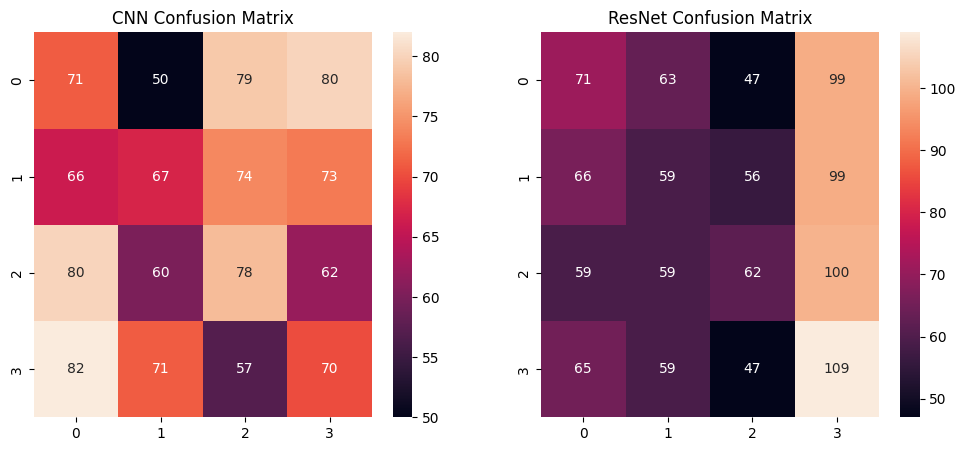

In [25]:
# ===============================
# CONFUSION MATRIX (CNN vs RESNET)
# ===============================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_cnn = confusion_matrix(true_classes, cnn_pred_classes)
cm_resnet = confusion_matrix(true_classes, resnet_pred_classes)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(cm_cnn, annot=True, fmt='d')
plt.title("CNN Confusion Matrix")

plt.subplot(1,2,2)
sns.heatmap(cm_resnet, annot=True, fmt='d')
plt.title("ResNet Confusion Matrix")

plt.show()

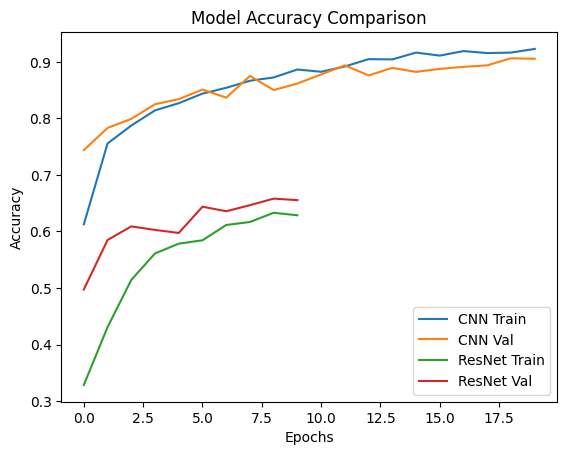

In [26]:
# ===============================
# ACCURACY COMPARISON
# ===============================

try:
    plt.plot(history_cnn.history['accuracy'], label='CNN Train')
    plt.plot(history_cnn.history['val_accuracy'], label='CNN Val')

    plt.plot(history_resnet.history['accuracy'], label='ResNet Train')
    plt.plot(history_resnet.history['val_accuracy'], label='ResNet Val')

    plt.legend()
    plt.title("Model Accuracy Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.show()

except:
    print("Training history not available (after reset)")

In [28]:
# ===============================
# SAFE IMAGE PREDICTION FUNCTION
# ===============================

def predict_image(model, img_path):
    img = cv2.imread(img_path)

    # Check if image loaded
    if img is None:
        print(" Error: Image not found. Check path:", img_path)
        return

    img = cv2.resize(img, (224,224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    class_index = np.argmax(pred)

    print(" Predicted Class:", class_index)

In [29]:
# ===============================
# IMPORTS FOR GRAD-CAM
# ===============================

import tensorflow as tf

In [30]:
# ===============================
# CHECK LAST CONV LAYER
# ===============================

for layer in resnet_model.layers:
    print(layer.name)

input_layer_1
conv1_pad
conv1_conv
conv1_bn
conv1_relu
pool1_pad
pool1_pool
conv2_block1_1_conv
conv2_block1_1_bn
conv2_block1_1_relu
conv2_block1_2_conv
conv2_block1_2_bn
conv2_block1_2_relu
conv2_block1_0_conv
conv2_block1_3_conv
conv2_block1_0_bn
conv2_block1_3_bn
conv2_block1_add
conv2_block1_out
conv2_block2_1_conv
conv2_block2_1_bn
conv2_block2_1_relu
conv2_block2_2_conv
conv2_block2_2_bn
conv2_block2_2_relu
conv2_block2_3_conv
conv2_block2_3_bn
conv2_block2_add
conv2_block2_out
conv2_block3_1_conv
conv2_block3_1_bn
conv2_block3_1_relu
conv2_block3_2_conv
conv2_block3_2_bn
conv2_block3_2_relu
conv2_block3_3_conv
conv2_block3_3_bn
conv2_block3_add
conv2_block3_out
conv3_block1_1_conv
conv3_block1_1_bn
conv3_block1_1_relu
conv3_block1_2_conv
conv3_block1_2_bn
conv3_block1_2_relu
conv3_block1_0_conv
conv3_block1_3_conv
conv3_block1_0_bn
conv3_block1_3_bn
conv3_block1_add
conv3_block1_out
conv3_block2_1_conv
conv3_block2_1_bn
conv3_block2_1_relu
conv3_block2_2_conv
conv3_block2_2_bn


In [31]:
# ===============================
# GRAD-CAM FUNCTION
# ===============================

def generate_gradcam(model, img_array, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

    return heatmap.numpy()

In [37]:
from google.colab import files
uploaded = files.upload()

Saving Te-gl_1.jpg to Te-gl_1.jpg


In [38]:
# ===============================
# SAFE IMAGE LOADING FOR GRAD-CAM
# ===============================

def preprocess_image(img_path):
    img = cv2.imread(img_path)

    if img is None:
        print(" Image not found! Check path:", img_path)
        return None

    img = cv2.resize(img, (224,224))
    img = img / 255.0
    return np.expand_dims(img, axis=0)

# Use correct file name here
img_path = "/content/Te-gl_1.jpg"

img_array = preprocess_image(img_path)

# Check before using
if img_array is not None:
    print(" Image loaded successfully")

 Image loaded successfully


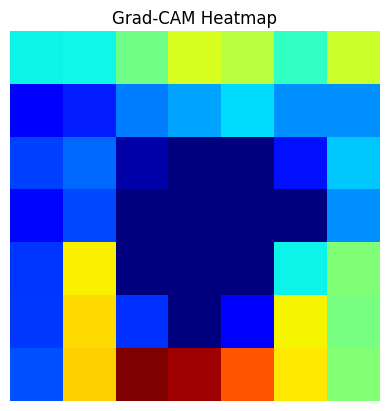

In [39]:
# ===============================
# GENERATE HEATMAP
# ===============================

heatmap = generate_gradcam(resnet_model, img_array, "conv5_block3_out")

plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis('off')
plt.show()

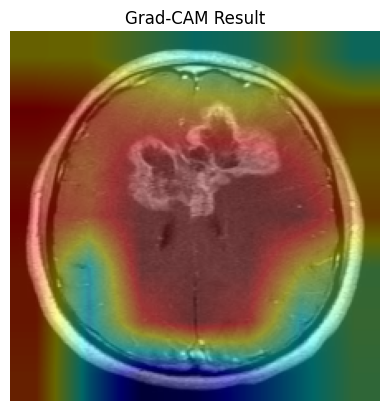

In [40]:
# ===============================
# OVERLAY HEATMAP ON IMAGE
# ===============================

img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))

heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)

heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

plt.imshow(superimposed_img)
plt.title("Grad-CAM Result")
plt.axis('off')
plt.show()

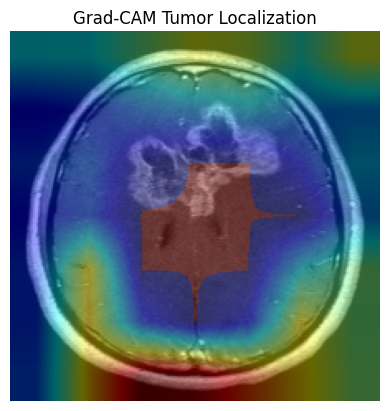

In [42]:
# ===============================
# OVERLAY HEATMAP ON ORIGINAL MRI
# ===============================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load original image
img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))

# Resize heatmap
heatmap_resized = cv2.resize(heatmap, (224,224))

# Convert to 0–255
heatmap_resized = np.uint8(255 * heatmap_resized)

# Apply color map
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

# Superimpose heatmap on image
superimposed_img = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

# Display
plt.imshow(superimposed_img)
plt.title("Grad-CAM Tumor Localization")
plt.axis('off')
plt.show()

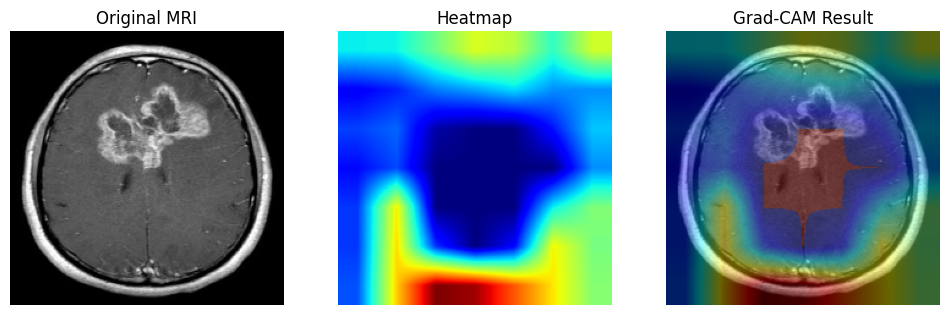

In [43]:
# ===============================
# ORIGINAL vs HEATMAP vs OVERLAY
# ===============================

plt.figure(figsize=(12,4))

# Original
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original MRI")
plt.axis('off')

# Heatmap
plt.subplot(1,3,2)
plt.imshow(heatmap, cmap='jet')
plt.title("Heatmap")
plt.axis('off')

# Overlay
plt.subplot(1,3,3)
plt.imshow(superimposed_img)
plt.title("Grad-CAM Result")
plt.axis('off')

plt.show()

In [44]:
# Save output image
cv2.imwrite("gradcam_output.jpg", superimposed_img)

True

In [45]:
pred = resnet_model.predict(img_array)
class_index = np.argmax(pred)
confidence = np.max(pred)

print("Predicted Class:", class_index)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted Class: 2
Confidence: 0.7191714
